1. Import the necessary libraries:


In [ ]:
import pandas as pd

In [ ]:
import numpy as np

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.axes as ax
from matplotlib.animation import FuncAnimation

2. Load the dataset and separate input and Target variables

In [ ]:
df = pd.read_csv('data.csv')

In [ ]:
print(df)

        x          y
0    24.0  21.549452
1    50.0  47.464463
2    15.0  17.218656
3    38.0  36.586398
4    87.0  87.288984
..    ...        ...
695  58.0  58.595006
696  93.0  94.625094
697  82.0  88.603770
698  66.0  63.648685
699  97.0  94.975266

[700 rows x 2 columns]


In [ ]:
df = df.dropna()

In [ ]:
train_input = np.array(df.x[0:500]).reshape(500, 1)
train_output = np.array(df.y[0:500]).reshape(500, 1)

test_input = np.array(df.x[500:700]).reshape(199, 1)
test_output = np.array(df.y[]).reshape(199, 1)500:700

In [ ]:
class LinearRegression:
    def __init__(self):
        self.parameters = {}

    def forward_propagation(self, train_input):
        m = self.parameters['m']
        c = self.parameters['c']
        predictions = np.multiply(m, train_input) + c
        return predictions

    def cost_function(self, predictions, train_output):
        cost = np.mean((train_output - predictions) ** 2)
        return cost

    def backward_propagation(self, train_input, train_output, predictions):
        derivatives = {}
        df = (predictions-train_output)
        dm = 2 * np.mean(np.multiply(train_input, df))
        dc = 2 * np.mean(df)
        derivatives['dm'] = dm
        derivatives['dc'] = dc
        return derivatives

    def update_parameters(self, derivatives, learning_rate):
        self.parameters['m'] = self.parameters['m'] - learning_rate * derivatives['dm']
        self.parameters['c'] = self.parameters['c'] - learning_rate * derivatives['dc']

    def train(self, train_input, train_output, learning_rate, iters):
        self.parameters['m'] = np.random.uniform(0, 1) * -1
        self.parameters['c'] = np.random.uniform(0, 1) * -1

        self.loss = []

        fig, ax = plt.subplots()
        x_vals = np.linspace(min(train_input), max(train_input), 100)
        line, = ax.plot(x_vals, self.parameters['m'] * x_vals + self.parameters['c'], color='red', label='Regression Line')
        ax.scatter(train_input, train_output, marker='o', color='green', label='Training Data')

        ax.set_ylim(0, max(train_output) + 1)

        def update(frame):
            predictions = self.forward_propagation(train_input)
            cost = self.cost_function(predictions, train_output)
            derivatives = self.backward_propagation(train_input, train_output, predictions)
            self.update_parameters(derivatives, learning_rate)
            line.set_ydata(self.parameters['m'] * x_vals + self.parameters['c'])
            self.loss.append(cost)
            print("Iteration = {}, Loss = {}".format(frame + 1, cost))
            return line,

        ani = FuncAnimation(fig, update, frames=iters, interval=200, blit=True)
        ani.save('linear_regression_A.gif', writer='ffmpeg')

        plt.xlabel('Input')
        plt.ylabel('Output')
        plt.title('Linear Regression')
        plt.legend()
        plt.show()

        return self.parameters, self.loss

Constructor initializes an empty dictionary self.parameters that will later hold the slope (m) and intercept (c) of the regression line.

In [ ]:
class LinearRegression:
    def __init__(self):
        self.parameters = {}

Purpose: Compute the predicted y values.

m = slope, c = intercept.

np.multiply(m, train_input) + c → implements the line equation:

y=mx+c

Returns the predicted values for given input.

In [ ]:
def forward_propagation(self, train_input):
        m = self.parameters['m']
        c = self.parameters['c']
        predictions = np.multiply(m, train_input) + c
        return predictions

Purpose: Calculate Mean Squared Error (MSE) between actual (train_output) and predicted values.

MSE
=
1
𝑛
∑
(
𝑦
true
−
𝑦
pred
)
2
MSE=
n
1
	​

∑(y
true
	​

−y
pred
	​

)
2

Returns the cost (a measure of how bad predictions are).

In [ ]:
 def cost_function(self, predictions, train_output):
        cost = np.mean((train_output - predictions) ** 2)
        return cost

Purpose: Compute gradients of cost function w.r.t parameters m and c.

df = predictions - train_output → error term.

dm → derivative of cost w.r.t slope
𝑚


dc → derivative of cost w.r.t intercept
c.

Both stored in dictionary derivatives.

In [ ]:
def backward_propagation(self, train_input, train_output, predictions):
        derivatives = {}
        df = (predictions-train_output)
        dm = 2 * np.mean(np.multiply(train_input, df))
        dc = 2 * np.mean(df)
        derivatives['dm'] = dm
        derivatives['dc'] = dc
        return derivatives

Purpose: Update slope (m) and intercept (c) using gradient descent.

Formula:


𝜃
−
𝛼
⋅
∂
𝐽
∂
𝜃
θ=θ−α⋅
∂θ
∂J
	​


where
𝛼
α = learning rate.

In [ ]:
def update_parameters(self, derivatives, learning_rate):
        self.parameters['m'] = self.parameters['m'] - learning_rate * derivatives['dm']
        self.parameters['c'] = self.parameters['c'] - learning_rate * derivatives['dc']

Purpose: Training function.

Initialize m and c randomly as small negative values.

In [ ]:
def train(self, train_input, train_output, learning_rate, iters):
        self.parameters['m'] = np.random.uniform(0, 1) * -1
        self.parameters['c'] = np.random.uniform(0, 1) * -1
        self.loss = []


Store cost after each iteration.

Create a plot.

x_vals = evenly spaced points to draw regression line.

Plot initial regression line (red).

Scatter training points (green).

Iteration = 1, Loss = 6568.988011649133
Iteration = 1, Loss = 798.5263036010047
Iteration = 1, Loss = 103.12286842227694
Iteration = 1, Loss = 19.31918527912788
Iteration = 2, Loss = 9.219928091093143
Iteration = 3, Loss = 8.002856331300286
Iteration = 4, Loss = 7.8561845775886265
Iteration = 5, Loss = 7.838507673550692
Iteration = 6, Loss = 7.836376052843233
Iteration = 7, Loss = 7.836117808088352
Iteration = 8, Loss = 7.836085325660215
Iteration = 9, Loss = 7.8360800501864745
Iteration = 10, Loss = 7.836078053583937
Iteration = 11, Loss = 7.836076452258161
Iteration = 12, Loss = 7.836074898704621
Iteration = 13, Loss = 7.83607335104523
Iteration = 14, Loss = 7.836071804233205
Iteration = 15, Loss = 7.83607025766034
Iteration = 16, Loss = 7.836068711253325
Iteration = 17, Loss = 7.836067165003316
Iteration = 18, Loss = 7.836065618909229
Iteration = 19, Loss = 7.836064072970923
Iteration = 20, Loss = 7.836062527188363


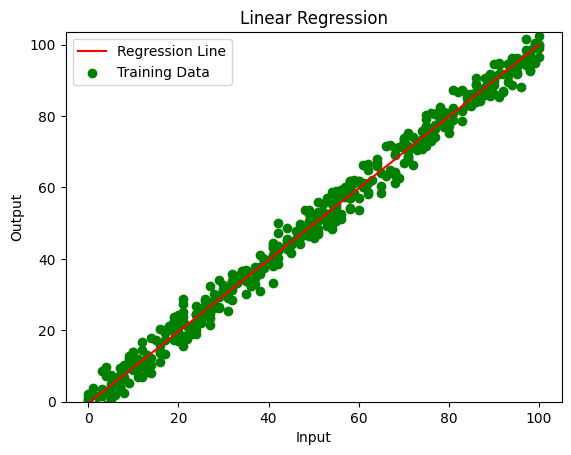

In [ ]:
linear_reg = LinearRegression()
parameters, loss = linear_reg.train(train_input, train_output, 0.0001, 20)